### overview 

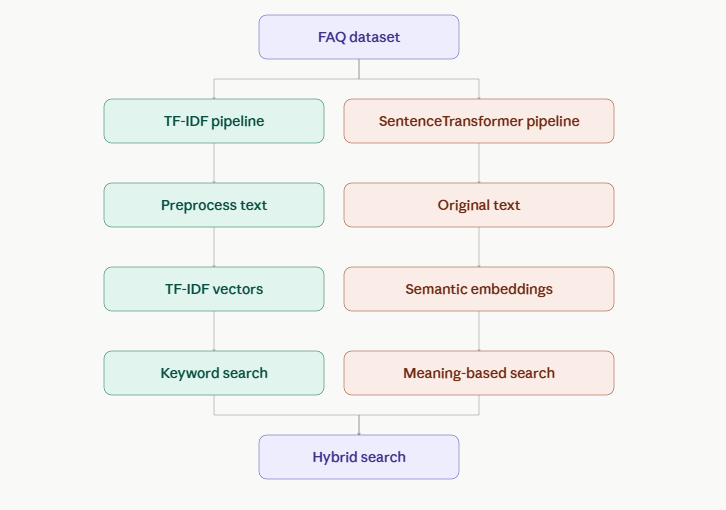

#### checking python version

In [1]:
import sys

print("Python executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

Python executable:
c:\Rowaida\AI-intern\small FAQ search engine project\venv\cenv\Scripts\python.exe

Python version:
3.13.9 (tags/v3.13.9:8183fa5, Oct 14 2025, 14:09:13) [MSC v.1944 64 bit (AMD64)]


#### check all installed libs

In [2]:
import numpy as np
import pandas as pd
import sklearn
import nltk
import datasets
import sentence_transformers

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)
print("NLTK:", nltk.__version__)
print("Datasets:", datasets.__version__)
print("Sentence Transformers:", sentence_transformers.__version__)

print("\nAll libraries imported successfully.")

NumPy: 2.5.1
Pandas: 3.0.5
Scikit-learn: 1.9.0
NLTK: 3.10.1
Datasets: 5.0.1
Sentence Transformers: 5.6.1

All libraries imported successfully.


### FQA data 

In [ ]:
from datasets import load_dataset #datassets is a huggingface library that provides a collection of ready-to-use datasets for NLP tasks. It allows users to easily access and load various datasets for training and evaluation of machine learning models.
dataset = load_dataset("gtfintechlab/banking77")
print(dataset) #display dataset  structure and information about the dataset, such as the number of samples, features, and labels. It provides an overview of the dataset's characteristics and can help users understand its composition before further analysis or model training.

README.md:   0%|          | 0.00/9.78k [00:00<?, ?B/s]

c:\Rowaida\AI-intern\small FAQ search engine project\venv\cenv\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Eng.Rowaida\.cache\huggingface\hub\datasets--gtfintechlab--banking77. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


data/train-00000-of-00001-86e794ae0661f6(…): reconstructing file:   0%|          |  0.00B /  298kB            

data/train-00000-of-00001-86e794ae0661f6(…): downloading bytes:           |  0.00B            

data/test-00000-of-00001-ca30debcf4e3446(…): reconstructing file:   0%|          |  0.00B / 93.9kB            

data/test-00000-of-00001-ca30debcf4e3446(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/10003 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3080 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 10003
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 3080
    })
})


In [7]:
dataset["train"][:5] #test

{'text': ['I am still waiting on my card?',
  "What can I do if my card still hasn't arrived after 2 weeks?",
  'I have been waiting over a week. Is the card still coming?',
  'Can I track my card while it is in the process of delivery?',
  'How do I know if I will get my card, or if it is lost?'],
 'label': [11, 11, 11, 11, 11]}

In [8]:
#see label/categ names 
label_names = dataset["train"].features["label"].names

print("Number of labels:", len(label_names))
print(label_names)

Number of labels: 77
['activate_my_card', 'age_limit', 'apple_pay_or_google_pay', 'atm_support', 'automatic_top_up', 'balance_not_updated_after_bank_transfer', 'balance_not_updated_after_cheque_or_cash_deposit', 'beneficiary_not_allowed', 'cancel_transfer', 'card_about_to_expire', 'card_acceptance', 'card_arrival', 'card_delivery_estimate', 'card_linking', 'card_not_working', 'card_payment_fee_charged', 'card_payment_not_recognised', 'card_payment_wrong_exchange_rate', 'card_swallowed', 'cash_withdrawal_charge', 'cash_withdrawal_not_recognised', 'change_pin', 'compromised_card', 'contactless_not_working', 'country_support', 'declined_card_payment', 'declined_cash_withdrawal', 'declined_transfer', 'direct_debit_payment_not_recognised', 'disposable_card_limits', 'edit_personal_details', 'exchange_charge', 'exchange_rate', 'exchange_via_app', 'extra_charge_on_statement', 'failed_transfer', 'fiat_currency_support', 'get_disposable_virtual_card', 'get_physical_card', 'getting_spare_card', '

In [9]:
first_sample = dataset["train"][0]
question = first_sample["text"] 
label_num = first_sample["label"]
label_name = label_names[label_num]

print("First sample question:", question)
print("Label number:", label_num)
print("Label name:", label_name)

First sample question: I am still waiting on my card?
Label number: 11
Label name: card_arrival


##### Convert the dataset to a Pandas table , Add readable category names , Combine train and test

In [12]:
train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

# Training questions become the searchable FAQ collection
corpus_df = train_df.copy().reset_index(drop=True)

# Test questions become unseen queries for evaluation
query_df = test_df.copy().reset_index(drop=True)

# Convert numeric labels into readable category names
corpus_df["category"] = corpus_df["label"].apply(
    lambda number: label_names[number]
)

query_df["category"] = query_df["label"].apply(
    lambda number: label_names[number]
)

# Inspect the corpus
print("Corpus shape:", corpus_df.shape)
print("Number of documents in corpus:", len(corpus_df))
print(
    "Number of categories in corpus:",
    corpus_df["category"].nunique()
)

# Inspect the query dataset
print("\nQuery shape:", query_df.shape)
print("Number of queries:", len(query_df))
print(
    "Number of categories in query:",
    query_df["category"].nunique()
)

# Check for missing values
print("\nMissing values in corpus:")
print(corpus_df.isnull().sum())

print("\nMissing values in query:")
print(query_df.isnull().sum())

Corpus shape: (10003, 3)
Number of documents in corpus: 10003
Number of categories in corpus: 77

Query shape: (3080, 3)
Number of queries: 3080
Number of categories in query: 77

Missing values in corpus:
text        0
label       0
category    0
dtype: int64

Missing values in query:
text        0
label       0
category    0
dtype: int64


In [15]:
corpus_df.head() #corpus_df -> stored questions searched by the engine

,text,label,category
0,I am still waiting on my card?,11,card_arrival
1,What can I do if my card still hasn't arrived ...,11,card_arrival
2,I have been waiting over a week. Is the card s...,11,card_arrival
3,Can I track my card while it is in the process...,11,card_arrival
4,"How do I know if I will get my card, or if it ...",11,card_arrival


In [16]:
query_df.head() #query_df2 -> unseen questions used to test the engine

,text,label,category
0,How do I locate my card?,11,card_arrival
1,"I still have not received my new card, I order...",11,card_arrival
2,I ordered a card but it has not arrived. Help ...,11,card_arrival
3,Is there a way to know when my card will arrive?,11,card_arrival
4,My card has not arrived yet.,11,card_arrival


##  TF-IDF lexical search pipeline

#### preprocess text

In [21]:
import re

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

#preprocessing objects

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))


print("nuumber of stop words:", len(stop_words))
print("example stop words:", list(stop_words)[:10])
print("example lemmatization:", lemmatizer.lemmatize("runs"))

nuumber of stop words: 198
example stop words: ['haven', 'when', 'yourselves', 'here', 'as', "i'd", 'having', 'it', "shouldn't", 'doesn']
example lemmatization: run


#### preprocessing function

In [22]:
def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    # Lowercase the text
    text = text.lower()
    # Extract words and remove punctuation
    tokens = re.findall(r"\b[a-zA-Z]+\b", text)
    # Remove stop words
    tokens = [words for words in tokens if words not in stop_words]
    # Lemmatize the tokens
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)

In [24]:
corpus_df["clean_text"] = corpus_df["text"].apply(preprocess_text)
corpus_df.head()

,text,label,category,clean_text
0,I am still waiting on my card?,11,card_arrival,still waiting card
1,What can I do if my card still hasn't arrived ...,11,card_arrival,card still arrived week
2,I have been waiting over a week. Is the card s...,11,card_arrival,waiting week card still coming
3,Can I track my card while it is in the process...,11,card_arrival,track card process delivery
4,"How do I know if I will get my card, or if it ...",11,card_arrival,know get card lost


In [27]:
import numpy as np
#Tool that converts documents into TF-IDF vectors.
from sklearn.feature_extraction.text import TfidfVectorizer 

#function that compares the query vector with document vectors.
from sklearn.metrics.pairwise import cosine_similarity

#Create the TF-IDF vectorizer , it creats TF-IDF object
from sklearn.metrics.pairwise import cosine_similarity

tfidf_vectorizer = TfidfVectorizer() #tool created
#fit the vectorizer on the corpus + transform the corpus into TF-IDF vectors
corpus_tfidf_matrix = tfidf_vectorizer.fit_transform(corpus_df["clean_text"])

corpus_tfidf_matrix.shape #(number of documents, number of unique terms in the corpus)

(10003, 2016)

#### search function

In [32]:
def tfidf_search(query, top_k=5):
    # Preprocess the query
    clean_query = preprocess_text(query)
    # Check if the query is empty after preprocessing
    if clean_query == "": #stop the search if the query is empty and display meaningful error message 
        raise ValueError("Query is empty after preprocessing. Please provide a valid query.")

    #Tranasform / Convert the query into a vector using the vocabulary already learned from the corpus.
    query_vector = tfidf_vectorizer.transform([clean_query])
    query_vector.shape #(1, number of unique terms in the corpus)

    #compare the query with all corpus documents using cosine similarity, which measures the similarity between two vectors based on the angle between them.
    scores = cosine_similarity(query_vector, corpus_tfidf_matrix).flatten()

    #find highest scoring documents and return their indices, which represent the most relevant documents in the corpus based on the query.
    top_indices = np.argsort(scores)[::-1][:top_k]

    #Retrieve the matching rows
    results = corpus_df.iloc[top_indices][['text', 'category']].copy()

    results.insert(0,"rank", range(1, len(results) + 1))

    results["score"] = scores[top_indices]
    results["method"] = "TF-IDF"

    return results.reset_index(drop=True)

In [33]:
#test function
my_query = "Where is the card that I ordered?"

results = tfidf_search( query=my_query,top_k=5 )

print("Query:", my_query)
print("results:\n", results)


Query: Where is the card that I ordered?
results:
    rank                                               text  \
0     1          I ordered my card but it still isn't here   
1     2                Where can virtual cards be ordered?   
2     3  I need to find out where the card is that I or...   
3     4      disposable virtual card can be ordered where?   
4     5           Where is the card I ordered 2 weeks ago?   

                      category     score  method  
0                 card_arrival  0.846120  TF-IDF  
1         getting_virtual_card  0.822856  TF-IDF  
2                 card_arrival  0.737407  TF-IDF  
3  get_disposable_virtual_card  0.713439  TF-IDF  
4                 card_arrival  0.681619  TF-IDF  


## SentenceTransformer semantic search pipeline

In [36]:
#load a pre-trained model from the Sentence Transformers library. The model is used to generate dense vector representations (embeddings) for text data, which can capture semantic meaning and relationships between words and sentences.
from sentence_transformers import SentenceTransformer
#creat model object
semantic_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2") # the model is used to generate dense vector representations (embeddings) for text data, which can capture semantic meaning and relationships between words and sentences.

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\Rowaida\AI-intern\small FAQ search engine project\venv\cenv\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Eng.Rowaida\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
#test embedding genaration
example_sentences = [
    "How can I activate my card?",
    "How do I start using my new card?"
]

example_embeddings = semantic_model.encode(
    example_sentences
)

print("Embedding shape:", example_embeddings.shape)
print("Embedding for first sentence:\n", example_embeddings[0])

Embedding shape: (2, 384)
Embedding for first sentence:
 [-1.86809078e-02 -7.59808049e-02 -6.44052625e-02  1.10105425e-03
  1.91201475e-02  1.40784041e-03  6.71426952e-02  3.76113206e-02
  1.34219881e-02 -5.00119999e-02  1.74757559e-02 -6.80648908e-03
 -2.14946475e-02  1.23272222e-02  9.47059169e-02 -2.38805953e-02
  2.20743380e-02  7.48582464e-03  1.87506154e-02  1.11046713e-02
  1.28207970e-02 -5.52471466e-02 -1.12467170e-01  1.49828494e-02
 -6.63656276e-03 -7.32395947e-02 -4.67636362e-02 -1.20356623e-02
  1.91908795e-02  3.54214758e-02  7.81823397e-02  6.66236281e-02
  8.64959061e-02 -2.96739675e-03  1.19814957e-02 -6.55555651e-02
 -1.53422374e-02 -4.32909932e-03 -9.05650761e-03 -8.42356682e-02
 -8.69762525e-03 -6.53288066e-02 -6.92425743e-02  4.15920876e-02
  3.23529169e-02 -2.39033066e-02  2.48166430e-03  1.05755858e-01
  2.44877357e-02 -7.43046636e-03  2.14239471e-02 -3.40255275e-02
 -5.07084019e-02 -6.39814809e-02 -1.14140645e-01  1.42296366e-02
  2.96304524e-02 -2.24621743e-02 

#### creat embedding for the entire corpus

In [41]:
corpus_embeddings = semantic_model.encode(
    corpus_df["clean_text"].tolist(), batch_size = 64 , show_progress_bar=True , normalize_embeddings=True,
    convert_to_numpy=True)

Batches:   0%|          | 0/157 [00:00<?, ?it/s]